In [1]:
#setup-imports-and-paths
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import solve_ivp

from IPython.display import display, Math
import sympy as sp

#project-root-path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

#figures-folder-path
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

#outputs-folder-path
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
OUTPUTS_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Figures folder:", FIGURES_DIR)
print("Outputs folder:", OUTPUTS_DIR)
print("Notebook setup complete.")

Project root: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project
Figures folder: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\figures
Outputs folder: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\outputs
Notebook setup complete.


In [29]:
#physical-parameters-dicke-superradiance
gamma0 = 0.0

#gammac-collective-cavity-decay-rate-parameter
gammac = 1.0

#time-grid-dimensionless-time-gammac-t
s_min = 0.0
s_max = 2.0
num_points = 3000
s_grid = np.linspace(s_min, s_max, num_points)

#physical-time-grid-t=s/gammac
t_grid = s_grid / gammac

print("gamma0 =", gamma0)
print("gammac =", gammac)
print("Using dimensionless time s = Gamma_c * t")

gamma0 = 0.0
gammac = 1.0
Using dimensionless time s = Gamma_c * t


In [30]:
#latex-dicke-rate-equation
display(Math(
    r"J_-|n\rangle = \sqrt{n(N-n+1)}\,|n-1\rangle"
))

display(Math(
    r"\Gamma_{n\rightarrow n-1} = \Gamma_c\,n(N-n+1)"
))

display(Math(
    r"\frac{dp_n}{dt} = \Gamma_c(n+1)(N-n)p_{n+1} - \Gamma_c n(N-n+1)p_n"
))

display(Math(
    r"P_e(t)=\sum_{n=0}^{N} n\,p_n(t)"
))

display(Math(
    r"R(t)=-\frac{dP_e}{dt}=\sum_{n=0}^{N}\Gamma_c n(N-n+1)p_n(t)"
))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [31]:
#dicke-decay-rate-function
def dicke_decay_rate(n, num_atoms, gammac):
    """
    #dicke-decay-rate-calc
    Computes the collective decay rate from |n> to |n-1>.

    #n-excitation-number-parameter
    n is the number of excited atoms.

    #num-atoms-parameter
    Total number of atoms N.

    #gammac-collective-cavity-decay-rate-parameter
    Collective cavity decay rate.
    """
    
    #rate-calc
    rate = gammac * n * (num_atoms - n + 1)
    
    return rate

In [32]:
#dicke-rate-equation-rhs-function
def dicke_rate_equation_rhs(t, p, num_atoms, gammac):
    """
    #dicke-rate-equation-calc
    Computes dp_n/dt for n = 0, 1, ..., N.

    #p-probability-vector-calc
    p[n] is the probability of having n excitations.

    #boundary-note
    p[0] is the ground state and has no outgoing collective decay.
    p[N] is initially populated for all atoms excited.
    """
    
    #probability-derivative-storage-calc
    dp_dt = np.zeros_like(p)
    
    for n in range(num_atoms + 1):
        
        #gain-from-state-n-plus-one-calc
        if n + 1 <= num_atoms:
            rate_from_np1_to_n = dicke_decay_rate(n + 1, num_atoms, gammac)
            dp_dt[n] += rate_from_np1_to_n * p[n + 1]
        
        #loss-from-state-n-to-n-minus-one-calc
        if n >= 1:
            rate_from_n_to_nm1 = dicke_decay_rate(n, num_atoms, gammac)
            dp_dt[n] -= rate_from_n_to_nm1 * p[n]
    
    return dp_dt

In [33]:
#solve-dicke-rate-equation-function
def solve_dicke_rate_equation(num_atoms, gammac, t_grid):
    """
    #solve-dicke-rate-equation-calc
    Solves the Dicke-basis rate equation for N atoms.

    #initial-condition
    p_N(0)=1 because all atoms start excited.
    """
    
    #initial-probability-vector-calc
    p0 = np.zeros(num_atoms + 1)
    p0[num_atoms] = 1.0
    
    #ode-solver-calc
    solution = solve_ivp(
        fun=lambda t, p: dicke_rate_equation_rhs(t, p, num_atoms, gammac),
        t_span=(t_grid[0], t_grid[-1]),
        y0=p0,
        t_eval=t_grid,
        method="RK45",
        rtol=1e-9,
        atol=1e-11,
    )
    
    if not solution.success:
        print("Solver failed for N =", num_atoms)
        print(solution.message)
    
    #probability-array-shape-time-by-excitation-number
    probabilities = solution.y.T
    
    return probabilities

In [34]:
#dicke-observables-function
def compute_dicke_observables(probabilities, num_atoms, gammac):
    """
    #dicke-observables-calc
    Computes total excited population P_e(t) and photon emission rate R(t).

    #probabilities-parameter
    probabilities[:, n] = p_n(t)

    #excited-population
    P_e(t) = sum_n n p_n(t)

    #emission-rate
    R(t) = sum_n Gamma_c n(N-n+1) p_n(t)
    """
    
    #excitation-number-array-calc
    n_values = np.arange(num_atoms + 1)
    
    #total-excited-population-calc
    total_excited_population = probabilities @ n_values
    
    #dicke-transition-rates-calc
    transition_rates = np.array([
        dicke_decay_rate(n, num_atoms, gammac)
        for n in n_values
    ])
    
    #photon-emission-rate-calc
    emission_rate = probabilities @ transition_rates
    
    return total_excited_population, emission_rate

In [35]:
#test-dicke-solver-for-one-N
test_N = 4

probabilities_test = solve_dicke_rate_equation(
    num_atoms=test_N,
    gammac=gammac,
    t_grid=t_grid,
)

P_e_test, R_test = compute_dicke_observables(
    probabilities=probabilities_test,
    num_atoms=test_N,
    gammac=gammac,
)

print("Probability shape:", probabilities_test.shape)
print("Initial total probability:", np.sum(probabilities_test[0]))
print("Final total probability:", np.sum(probabilities_test[-1]))
print("Initial P_e:", P_e_test[0])
print("Final P_e:", P_e_test[-1])
print("Initial R:", R_test[0])
print("Peak R:", np.max(R_test))

Probability shape: (3000, 5)
Initial total probability: 1.0
Final total probability: 0.9999999999999994
Initial P_e: 4.0
Final P_e: 0.01971488936042448
Initial R: 4.0
Peak R: 4.857408471359199


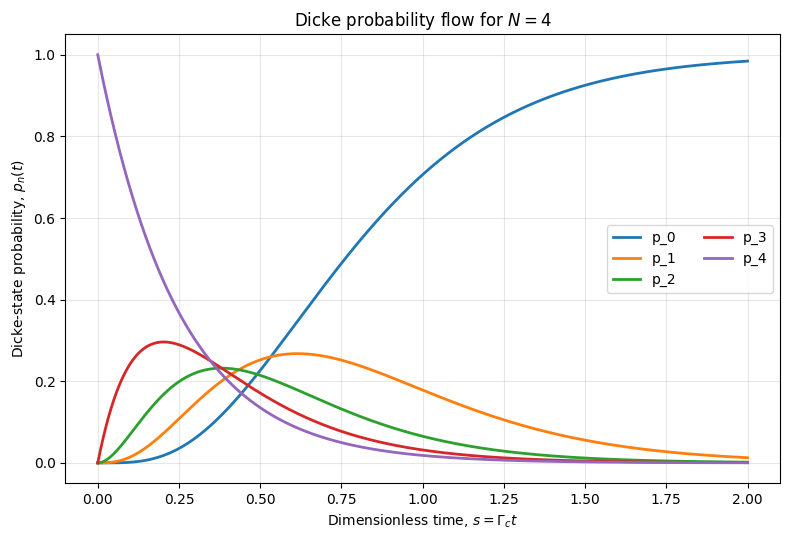

Saved figure to: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\figures\dicke_probability_flow_N4.png


In [36]:
#plot-dicke-probability-ladder-test
plt.figure(figsize=(8, 5.5))

for n in range(test_N + 1):
    plt.plot(
        s_grid,
        probabilities_test[:, n],
        linewidth=2,
        label=f"p_{n}",
    )

plt.xlabel(r"Dimensionless time, $s=\Gamma_c t$")
plt.ylabel(r"Dicke-state probability, $p_n(t)$")
plt.title(rf"Dicke probability flow for $N={test_N}$")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()

figure_path = FIGURES_DIR / f"dicke_probability_flow_N{test_N}.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)

In [37]:
#solve-dicke-superradiance-for-several-N
atom_numbers = [2, 4, 6, 8, 10, 12, 16, 20, 30, 40, 60, 80, 100]

#storage-dictionaries-calc
dicke_probabilities = {}
dicke_populations = {}
dicke_emission_rates = {}

for num_atoms in atom_numbers:
    
    print(f"Solving Dicke rate equation for N = {num_atoms}")
    
    probabilities = solve_dicke_rate_equation(
        num_atoms=num_atoms,
        gammac=gammac,
        t_grid=t_grid,
    )
    
    P_e, R = compute_dicke_observables(
        probabilities=probabilities,
        num_atoms=num_atoms,
        gammac=gammac,
    )
    
    dicke_probabilities[num_atoms] = probabilities
    dicke_populations[num_atoms] = P_e
    dicke_emission_rates[num_atoms] = R

print("Done.")

Solving Dicke rate equation for N = 2
Solving Dicke rate equation for N = 4
Solving Dicke rate equation for N = 6
Solving Dicke rate equation for N = 8
Solving Dicke rate equation for N = 10
Solving Dicke rate equation for N = 12
Solving Dicke rate equation for N = 16
Solving Dicke rate equation for N = 20
Solving Dicke rate equation for N = 30
Solving Dicke rate equation for N = 40
Solving Dicke rate equation for N = 60
Solving Dicke rate equation for N = 80
Solving Dicke rate equation for N = 100
Done.


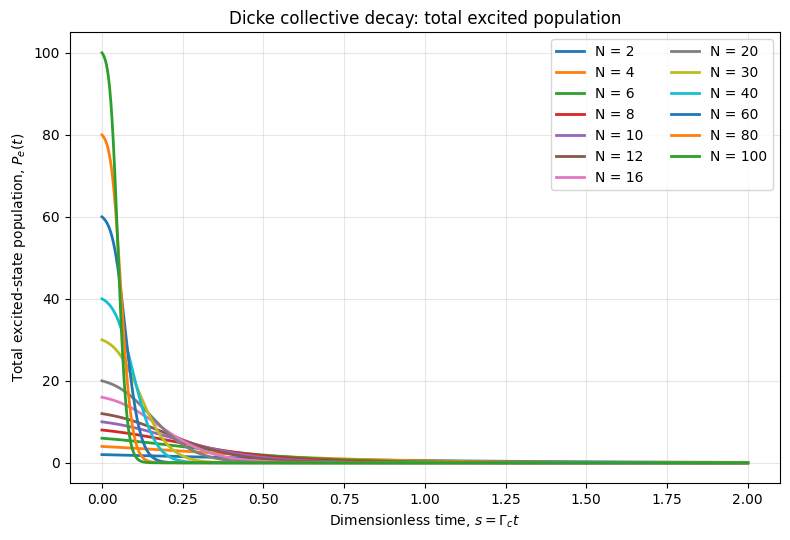

Saved figure to: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\figures\dicke_total_excited_population.png


In [38]:
#plot-dicke-total-excited-population
plt.figure(figsize=(8, 5.5))

for num_atoms in atom_numbers:
    plt.plot(
        s_grid,
        dicke_populations[num_atoms],
        linewidth=2,
        label=f"N = {num_atoms}",
    )

plt.xlabel(r"Dimensionless time, $s=\Gamma_c t$")
plt.ylabel(r"Total excited-state population, $P_e(t)$")
plt.title(r"Dicke collective decay: total excited population")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()

figure_path = FIGURES_DIR / "dicke_total_excited_population.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)

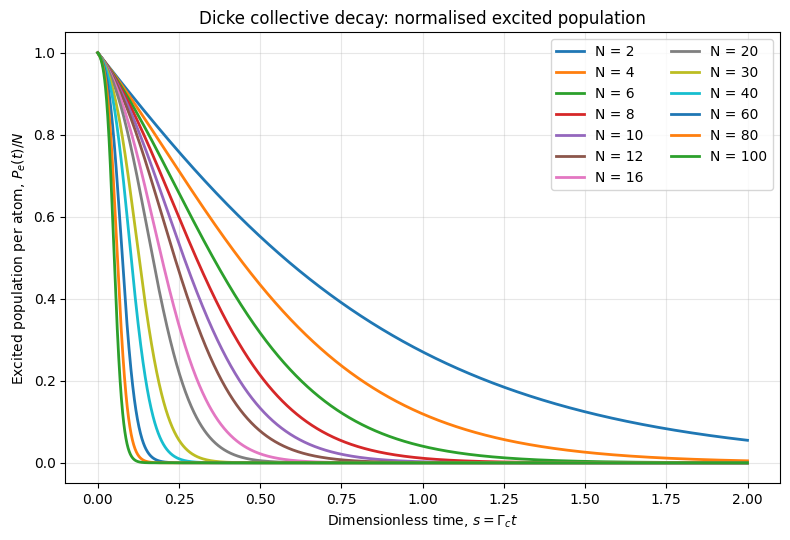

Saved figure to: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\figures\dicke_normalised_excited_population.png


In [39]:
#plot-dicke-normalised-excited-population
plt.figure(figsize=(8, 5.5))

for num_atoms in atom_numbers:
    plt.plot(
        s_grid,
        dicke_populations[num_atoms] / num_atoms,
        linewidth=2,
        label=f"N = {num_atoms}",
    )

plt.xlabel(r"Dimensionless time, $s=\Gamma_c t$")
plt.ylabel(r"Excited population per atom, $P_e(t)/N$")
plt.title(r"Dicke collective decay: normalised excited population")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()

figure_path = FIGURES_DIR / "dicke_normalised_excited_population.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)

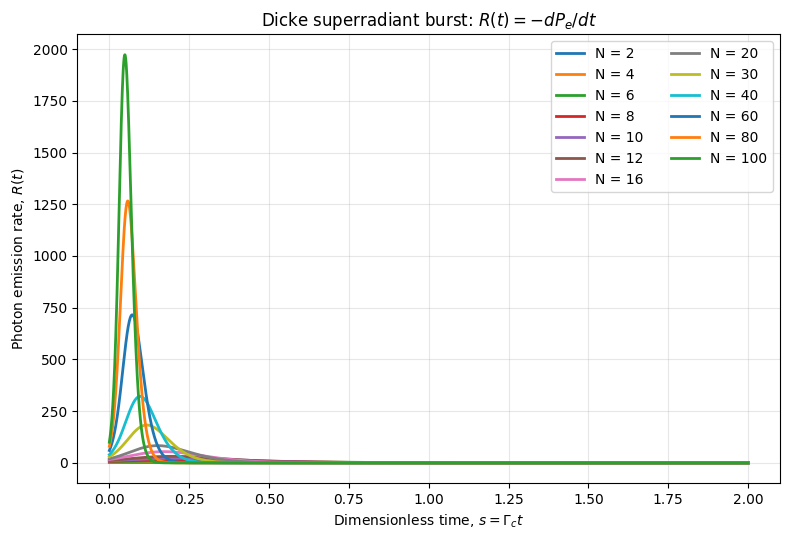

Saved figure to: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\figures\dicke_superradiant_burst_emission_rate.png


In [40]:
#plot-dicke-emission-rate-superradiant-burst
plt.figure(figsize=(8, 5.5))

for num_atoms in atom_numbers:
    plt.plot(
        s_grid,
        dicke_emission_rates[num_atoms],
        linewidth=2,
        label=f"N = {num_atoms}",
    )

plt.xlabel(r"Dimensionless time, $s=\Gamma_c t$")
plt.ylabel(r"Photon emission rate, $R(t)$")
plt.title(r"Dicke superradiant burst: $R(t)=-dP_e/dt$")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()

figure_path = FIGURES_DIR / "dicke_superradiant_burst_emission_rate.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)

In [41]:
#extract-superradiant-peak-data
peak_rows = []

for num_atoms in atom_numbers:
    
    R = dicke_emission_rates[num_atoms]
    
    #peak-index-calc
    peak_index = np.argmax(R)
    
    #peak-rate-calc
    peak_rate = R[peak_index]
    
    #peak-time-calc
    peak_time = s_grid[peak_index]
    
    peak_rows.append({
        "N": num_atoms,
        "Peak emission rate R_peak": peak_rate,
        "Peak time Gamma_c t_peak": peak_time,
        "R_peak / N": peak_rate / num_atoms,
        "R_peak / N^2": peak_rate / (num_atoms ** 2),
    })

peak_table = pd.DataFrame(peak_rows)

peak_csv_path = OUTPUTS_DIR / "dicke_superradiance_peak_scaling.csv"
peak_table.to_csv(peak_csv_path, index=False)

print("Saved peak table to:", peak_csv_path)
peak_table

Saved peak table to: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\outputs\dicke_superradiance_peak_scaling.csv


,N,Peak emission rate R_peak,Peak time Gamma_c t_peak,R_peak / N,R_peak / N^2
0,2,2.000000,0.000000,1.000000,0.500000
1,4,4.857408,0.213404,1.214352,0.303588
2,6,9.285168,0.236746,1.547528,0.257921
3,8,15.251810,0.228076,1.906476,0.238310
4,10,22.759116,0.212738,2.275912,0.227591
5,12,31.810522,0.197399,2.650877,0.220906
6,16,54.557244,0.171390,3.409828,0.213114
7,20,83.509441,0.151384,4.175472,0.208774
8,30,183.102318,0.117372,6.103411,0.203447
9,40,321.639914,0.096032,8.040998,0.201025


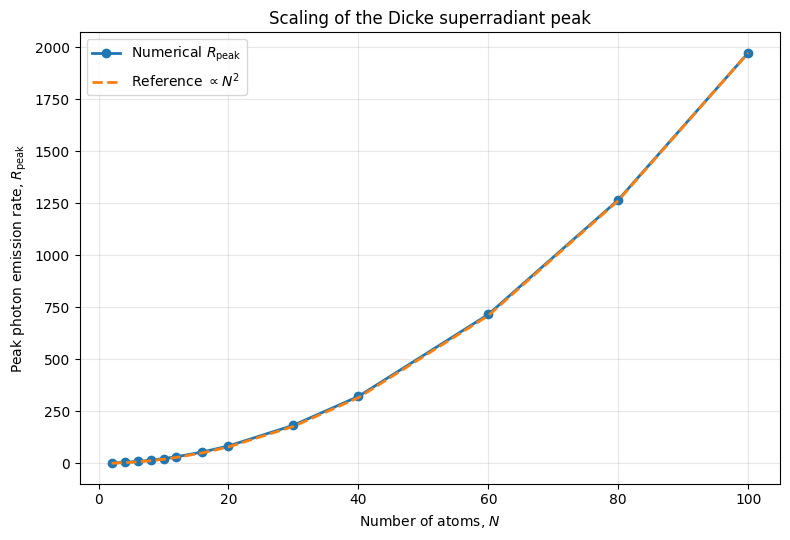

Saved figure to: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\figures\dicke_peak_emission_rate_scaling.png


In [42]:
#plot-peak-emission-rate-vs-N
plt.figure(figsize=(8, 5.5))

plt.plot(
    peak_table["N"],
    peak_table["Peak emission rate R_peak"],
    marker="o",
    linewidth=2,
    label=r"Numerical $R_{\mathrm{peak}}$",
)

#comparison-N2-scaling-calc
N_fit = np.array(peak_table["N"])
scale_factor = peak_table["Peak emission rate R_peak"].iloc[-1] / (N_fit[-1] ** 2)

plt.plot(
    N_fit,
    scale_factor * N_fit**2,
    "--",
    linewidth=2,
    label=r"Reference $\propto N^2$",
)

plt.xlabel(r"Number of atoms, $N$")
plt.ylabel(r"Peak photon emission rate, $R_{\mathrm{peak}}$")
plt.title(r"Scaling of the Dicke superradiant peak")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

figure_path = FIGURES_DIR / "dicke_peak_emission_rate_scaling.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)

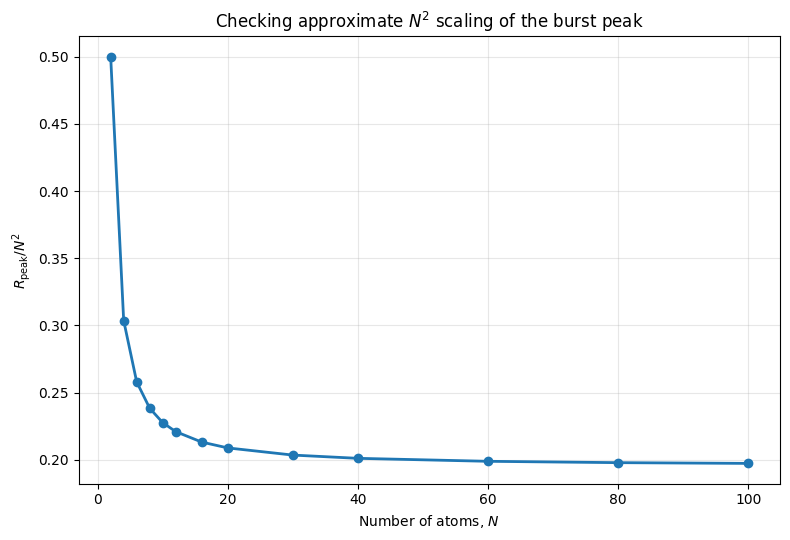

Saved figure to: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\figures\dicke_peak_emission_rate_over_N_squared.png


In [43]:
#plot-normalised-peak-scaling
plt.figure(figsize=(8, 5.5))

plt.plot(
    peak_table["N"],
    peak_table["R_peak / N^2"],
    marker="o",
    linewidth=2,
)

plt.xlabel(r"Number of atoms, $N$")
plt.ylabel(r"$R_{\mathrm{peak}}/N^2$")
plt.title(r"Checking approximate $N^2$ scaling of the burst peak")
plt.grid(True, alpha=0.3)
plt.tight_layout()

figure_path = FIGURES_DIR / "dicke_peak_emission_rate_over_N_squared.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)

In [45]:
#fit-power-law-scaling
#use-larger-N-values-for-fit-to-reduce-small-N-effects
fit_table = peak_table[peak_table["N"] >= 8]

log_N = np.log(fit_table["N"].to_numpy())
log_Rpeak = np.log(fit_table["Peak emission rate R_peak"].to_numpy())

#linear-fit-in-log-log-space
fit_slope, fit_intercept = np.polyfit(log_N, log_Rpeak, 1)

print("Power-law fit: R_peak ≈ A N^beta")
print("beta =", fit_slope)
print("A =", np.exp(fit_intercept))

Power-law fit: R_peak ≈ A N^beta
beta = 1.9315386505845002
A = 0.2632458828495978


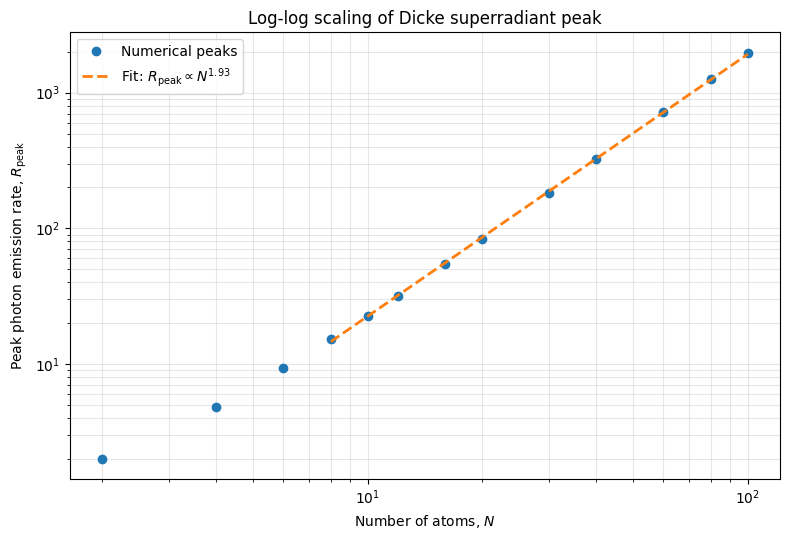

Saved figure to: c:\Users\ivraa\Documents\GitHub\optics-master-equation-project\figures\dicke_peak_scaling_loglog_fit.png


In [46]:
#plot-loglog-peak-scaling-with-fit
N_plot = np.linspace(min(fit_table["N"]), max(fit_table["N"]), 200)
R_fit = np.exp(fit_intercept) * N_plot**fit_slope

plt.figure(figsize=(8, 5.5))

plt.loglog(
    peak_table["N"],
    peak_table["Peak emission rate R_peak"],
    "o",
    label="Numerical peaks",
)

plt.loglog(
    N_plot,
    R_fit,
    "--",
    linewidth=2,
    label=rf"Fit: $R_\mathrm{{peak}}\propto N^{{{fit_slope:.2f}}}$",
)

plt.xlabel(r"Number of atoms, $N$")
plt.ylabel(r"Peak photon emission rate, $R_{\mathrm{peak}}$")
plt.title(r"Log-log scaling of Dicke superradiant peak")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()

figure_path = FIGURES_DIR / "dicke_peak_scaling_loglog_fit.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)

In [47]:
#report-note-dicke-superradiance
print(
    "For Gamma_0 = 0, the atoms decay only through the collective cavity channel. "
    "Since all atoms are initially excited and located at cavity antinodes, the dynamics remains "
    "inside the symmetric Dicke manifold, whose dimension is N+1 rather than 2^N. "
    "The photon emission rate R(t) is non-monotonic: it initially increases as population builds "
    "in strongly emitting Dicke states, reaches a superradiant burst peak, and then decays as the "
    "system approaches the ground state. The extracted peak emission rate grows approximately "
    "quadratically with N, consistent with collective Dicke enhancement."
)

For Gamma_0 = 0, the atoms decay only through the collective cavity channel. Since all atoms are initially excited and located at cavity antinodes, the dynamics remains inside the symmetric Dicke manifold, whose dimension is N+1 rather than 2^N. The photon emission rate R(t) is non-monotonic: it initially increases as population builds in strongly emitting Dicke states, reaches a superradiant burst peak, and then decays as the system approaches the ground state. The extracted peak emission rate grows approximately quadratically with N, consistent with collective Dicke enhancement.
